In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("../dataset/industrial_safety.csv")

df.head()

,Gas_Level,Temperature,Pressure,Humidity,Worker_Count,Maintenance_Status,Permit_Type,Shift,Explosion_Risk,Fire_Risk,Gas_Leakage_Risk,Electrical_Hazard,Worker_Safety_Score
0,62.93,30.01,5.38,64,30,Yes,Confined Space,Night,Medium,Low,Medium,Medium,45
1,21.04,79.98,3.92,84,8,Yes,Confined Space,Evening,Low,Medium,Low,Low,80
2,35.41,79.97,2.60,77,25,Yes,Confined Space,Evening,Low,Medium,Low,Low,70
3,0.99,32.86,2.78,79,21,Yes,Confined Space,Night,Low,Low,Low,Low,70
4,20.62,20.29,6.59,46,28,No,Hot Work,Morning,Low,Low,Low,Medium,80


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gas_Level            10000 non-null  float64
 1   Temperature          10000 non-null  float64
 2   Pressure             10000 non-null  float64
 3   Humidity             10000 non-null  int64  
 4   Worker_Count         10000 non-null  int64  
 5   Maintenance_Status   10000 non-null  str    
 6   Permit_Type          10000 non-null  str    
 7   Shift                10000 non-null  str    
 8   Explosion_Risk       10000 non-null  str    
 9   Fire_Risk            10000 non-null  str    
 10  Gas_Leakage_Risk     10000 non-null  str    
 11  Electrical_Hazard    10000 non-null  str    
 12  Worker_Safety_Score  10000 non-null  int64  
dtypes: float64(3), int64(3), str(7)
memory usage: 1015.8 KB


In [4]:
# Encode Input Features
df["Maintenance_Status"] = df["Maintenance_Status"].map({
    "No": 0,
    "Yes": 1
})

df["Permit_Type"] = df["Permit_Type"].map({
    "Normal": 0,
    "Hot Work": 1,
    "Confined Space": 2
})

df["Shift"] = df["Shift"].map({
    "Morning": 0,
    "Evening": 1,
    "Night": 2
})

# Encode Target Columns
risk_map = {
    "High": 0,
    "Low": 1,
    "Medium": 2
}

df["Explosion_Risk"] = df["Explosion_Risk"].map(risk_map)
df["Fire_Risk"] = df["Fire_Risk"].map(risk_map)
df["Gas_Leakage_Risk"] = df["Gas_Leakage_Risk"].map(risk_map)
df["Electrical_Hazard"] = df["Electrical_Hazard"].map(risk_map)

In [5]:
df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gas_Level            10000 non-null  float64
 1   Temperature          10000 non-null  float64
 2   Pressure             10000 non-null  float64
 3   Humidity             10000 non-null  int64  
 4   Worker_Count         10000 non-null  int64  
 5   Maintenance_Status   10000 non-null  int64  
 6   Permit_Type          10000 non-null  int64  
 7   Shift                10000 non-null  int64  
 8   Explosion_Risk       10000 non-null  int64  
 9   Fire_Risk            10000 non-null  int64  
 10  Gas_Leakage_Risk     10000 non-null  int64  
 11  Electrical_Hazard    10000 non-null  int64  
 12  Worker_Safety_Score  10000 non-null  int64  
dtypes: float64(3), int64(10)
memory usage: 1015.8 KB


,Gas_Level,Temperature,Pressure,Humidity,Worker_Count,Maintenance_Status,Permit_Type,Shift,Explosion_Risk,Fire_Risk,Gas_Leakage_Risk,Electrical_Hazard,Worker_Safety_Score
0,62.93,30.01,5.38,64,30,1,2,2,2,1,2,2,45
1,21.04,79.98,3.92,84,8,1,2,1,1,2,1,1,80
2,35.41,79.97,2.60,77,25,1,2,1,1,2,1,1,70
3,0.99,32.86,2.78,79,21,1,2,2,1,1,1,1,70
4,20.62,20.29,6.59,46,28,0,1,0,1,1,1,2,80


In [6]:
explosion_model = joblib.load("../saved_models/explosion_risk_model.pkl")
fire_model = joblib.load("../saved_models/fire_risk_model.pkl")
gas_model = joblib.load("../saved_models/gas_leakage_model.pkl")
electrical_model = joblib.load("../saved_models/electrical_hazard_model.pkl")
worker_model = joblib.load("../saved_models/worker_safety_model.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [7]:
X = df[[
    "Gas_Level",
    "Temperature",
    "Pressure",
    "Humidity",
    "Worker_Count",
    "Maintenance_Status",
    "Permit_Type",
    "Shift"
]]

X.head()

,Gas_Level,Temperature,Pressure,Humidity,Worker_Count,Maintenance_Status,Permit_Type,Shift
0,62.93,30.01,5.38,64,30,1,2,2
1,21.04,79.98,3.92,84,8,1,2,1
2,35.41,79.97,2.60,77,25,1,2,1
3,0.99,32.86,2.78,79,21,1,2,2
4,20.62,20.29,6.59,46,28,0,1,0


In [8]:
y_explosion = df["Explosion_Risk"]

print(y_explosion.head())

0    2
1    1
2    1
3    1
4    1
Name: Explosion_Risk, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_explosion,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 8000
Testing Samples  : 2000


In [10]:
y_pred = explosion_model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 2 2 1 1 1 1]


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Explosion Risk Accuracy:", round(accuracy * 100, 2), "%")

Explosion Risk Accuracy: 100.0 %


In [13]:
print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00      1163
           2       1.00      1.00      1.00       683

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix\n")

print(cm)

Confusion Matrix

[[ 154    0    0]
 [   0 1163    0]
 [   0    0  683]]


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

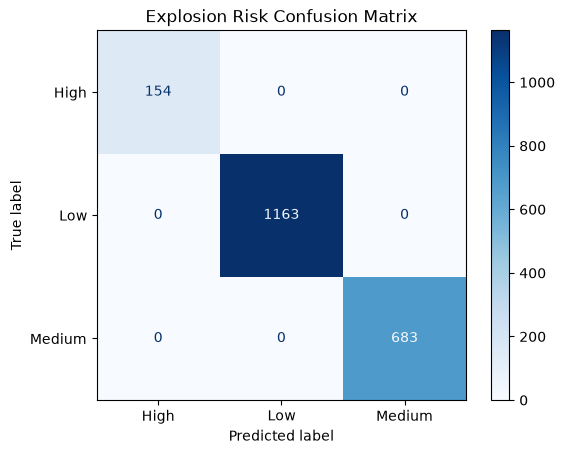

In [16]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Low", "Medium"]
)

disp.plot(cmap="Blues")

plt.title("Explosion Risk Confusion Matrix")

plt.show()

In [17]:
importance = explosion_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,Gas_Level,0.868524
1,Temperature,0.088711
2,Pressure,0.015086
3,Humidity,0.010990
4,Worker_Count,0.009439
7,Shift,0.002831
6,Permit_Type,0.002654
5,Maintenance_Status,0.001764


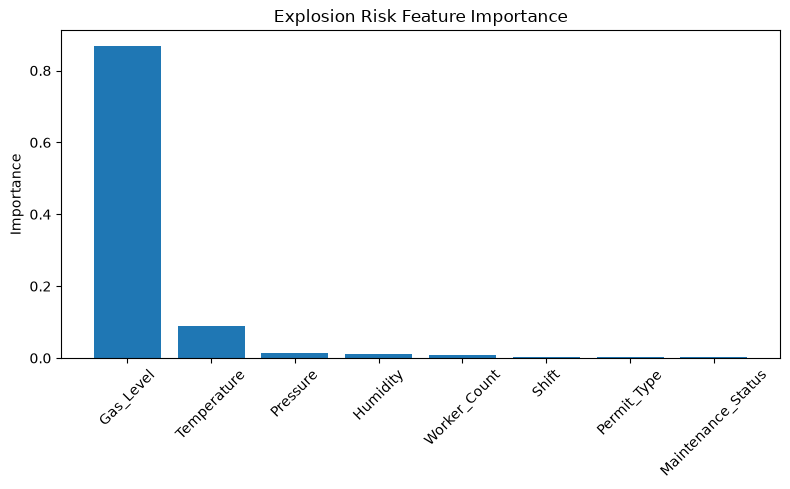

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Explosion Risk Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X, y, model_name):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy : {accuracy*100:.2f}%\n")

    print("Classification Report")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\n")

In [20]:
y_fire = df["Fire_Risk"]

evaluate_model(
    fire_model,
    X,
    y_fire,
    "Fire Risk Model"
)

Fire Risk Model
Accuracy : 100.00%

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       496
           1       1.00      1.00      1.00      1003
           2       1.00      1.00      1.00       501

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix
[[ 496    0    0]
 [   0 1003    0]
 [   0    0  501]]




In [21]:
y_gas = df["Gas_Leakage_Risk"]

evaluate_model(
    gas_model,
    X,
    y_gas,
    "Gas Leakage Risk Model"
)

Gas Leakage Risk Model
Accuracy : 37.65%

Classification Report
              precision    recall  f1-score   support

           0       0.26      0.26      0.26       505
           1       0.50      0.51      0.50       977
           2       0.25      0.24      0.24       518

    accuracy                           0.38      2000
   macro avg       0.34      0.34      0.34      2000
weighted avg       0.37      0.38      0.37      2000

Confusion Matrix
[[130 242 133]
 [234 499 244]
 [132 262 124]]




In [22]:
y_electrical = df["Electrical_Hazard"]

evaluate_model(
    electrical_model,
    X,
    y_electrical,
    "Electrical Hazard Model"
)

Electrical Hazard Model
Accuracy : 100.00%

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       445
           1       1.00      1.00      1.00       892
           2       1.00      1.00      1.00       663

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix
[[445   0   0]
 [  0 892   0]
 [  0   0 663]]




In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_worker = df["Worker_Safety_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_worker,
    test_size=0.2,
    random_state=42
)

y_pred = worker_model.predict(X_test)

print("="*60)
print("Worker Safety Score Model")
print("="*60)

print("Mean Absolute Error (MAE):", round(mean_absolute_error(y_test, y_pred), 2))
print("Mean Squared Error (MSE):", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 4))

Worker Safety Score Model
Mean Absolute Error (MAE): 0.34
Mean Squared Error (MSE): 1.13
R² Score: 0.9967


In [25]:
models = {
    "Explosion Risk": (explosion_model, df["Explosion_Risk"]),
    "Fire Risk": (fire_model, df["Fire_Risk"]),
    "Gas Leakage": (gas_model, df["Gas_Leakage_Risk"]),
    "Electrical Hazard": (electrical_model, df["Electrical_Hazard"])
}

results = []

for name, (model, target) in models.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        target,
        test_size=0.2,
        random_state=42
    )

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, round(acc*100,2)])

result_df = pd.DataFrame(results, columns=["Model","Accuracy (%)"])

result_df

,Model,Accuracy (%)
0,Explosion Risk,100.00
1,Fire Risk,100.00
2,Gas Leakage,37.65
3,Electrical Hazard,100.00


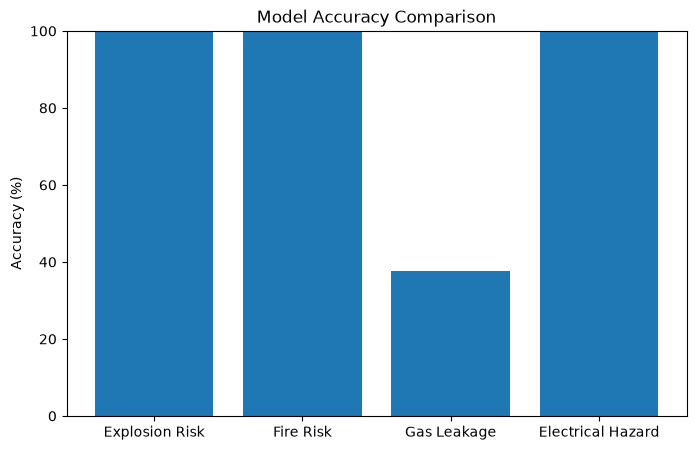

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    result_df["Model"],
    result_df["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy Comparison")

plt.ylim(0,100)

plt.show()

In [27]:
result_df.to_csv("../dataset/model_accuracy_results.csv", index=False)

print("Model evaluation results saved successfully!")

Model evaluation results saved successfully!
